# 🛡️ ScamShield AI

# AI-Powered SMS Scam & Spam Detection System

ScamShield AI is a machine learning project that analyzes SMS messages
and detects whether a message is legitimate or suspicious.

### Key Features
- SMS Spam Detection
- TF-IDF Text Vectorization
- Machine Learning Model Comparison
- SVM-based Final Model
- Scam Risk Assessment
- Red Flag Detection
- Scam Type Detection
- Confusion Matrix Evaluation

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [38]:
import zipfile
import os

zip_file_path = '/content/sms+spam+collection.zip'
extraction_path = '/content/sms_data'

# Create directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}'")
# List the extracted files to find the CSV
print("Extracted files:")
for root, dirs, files in os.walk(extraction_path):
    for file in files:
        print(os.path.join(root, file))

'/content/sms+spam+collection.zip' unzipped to '/content/sms_data'
Extracted files:
/content/sms_data/readme
/content/sms_data/SMSSpamCollection


In [39]:
# Assuming the extracted file is named 'SMSSpamCollection'
data_file_path = os.path.join(extraction_path, 'SMSSpamCollection')

# Load the dataset. The dataset typically has no header and two columns, separated by a tab.
df = pd.read_csv(data_file_path, sep='\t', header=None, names=['label', 'message'])

# Display the first 5 rows of the DataFrame
display(df.head(20))

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [40]:
print("Dataset Shape:", df.shape)

print("\nClass Distribution:")
print(df["label"].value_counts())

Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [41]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Check duplicate messages
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
label      0
message    0
dtype: int64

Duplicate rows: 403


In [42]:
df = df.drop_duplicates()
print("After removing duplicates:")
print("Dataset Shape:", df.shape)

After removing duplicates:
Dataset Shape: (5169, 2)


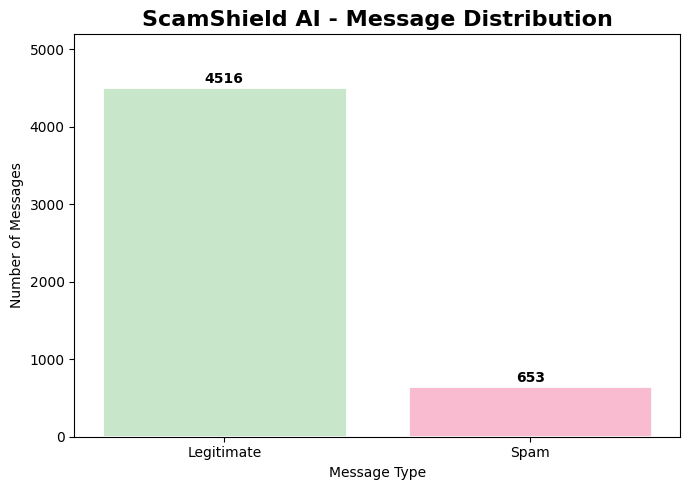

In [43]:
import matplotlib.pyplot as plt

counts = df["label"].value_counts()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Legitimate", "Spam"],
    [counts["ham"], counts["spam"]],
    color=["#C8E6C9", "#F8BBD0"],
    edgecolor="white",
    linewidth=2
)

plt.title(
    "ScamShield AI - Message Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

# Show numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        str(int(height)),
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

In [44]:
from sklearn.model_selection import train_test_split

X = df["message"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4135
Testing messages: 1034


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (4135, 7414)
Testing data shape: (1034, 7414)


## 🤖 Model Development

Three machine learning models are trained and compared:

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Machine (SVM)

The models are trained using TF-IDF transformed SMS messages.

In [46]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()

model_nb.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [47]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_nb = model_nb.predict(X_test_tfidf)

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9671179883945842

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       1.00      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.96      1034



In [48]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_tfidf, y_train)

y_pred_lr = model_lr.predict(X_test_tfidf)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9564796905222437

Classification Report:
              precision    recall  f1-score   support

         ham       0.95      1.00      0.98       903
        spam       0.98      0.67      0.80       131

    accuracy                           0.96      1034
   macro avg       0.97      0.83      0.89      1034
weighted avg       0.96      0.96      0.95      1034



In [49]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC()

model_svm.fit(X_train_tfidf, y_train)

y_pred_svm = model_svm.predict(X_test_tfidf)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", accuracy_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.9777562862669246

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.97      0.85      0.91       131

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Naive Bayes": y_pred_nb,
    "Logistic Regression": y_pred_lr,
    "Linear SVM": y_pred_svm
}

results = []

for name, predictions in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, pos_label="spam"),
        "Recall": recall_score(y_test, predictions, pos_label="spam"),
        "F1 Score": f1_score(y_test, predictions, pos_label="spam")
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0          Naive Bayes    0.9671     1.0000  0.7405    0.8509
1  Logistic Regression    0.9565     0.9778  0.6718    0.7964
2           Linear SVM    0.9778     0.9655  0.8550    0.9069


In [51]:
from sklearn.calibration import CalibratedClassifierCV

# Final SVM model with probability support
final_svm = CalibratedClassifierCV(
    LinearSVC(),
    method="sigmoid",
    cv=5
)

final_svm.fit(X_train_tfidf, y_train)

print("Final SVM model trained successfully!")

Final SVM model trained successfully!


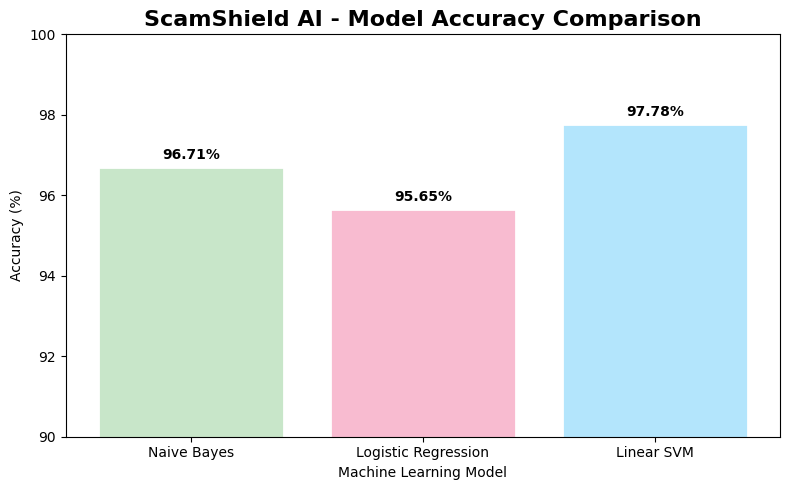

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"] * 100,
    color=["#C8E6C9", "#F8BBD0", "#B3E5FC"],
    edgecolor="white",
    linewidth=2
)

plt.title(
    "ScamShield AI - Model Accuracy Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.ylim(90, 100)

for bar, value in zip(bars, results_df["Accuracy"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

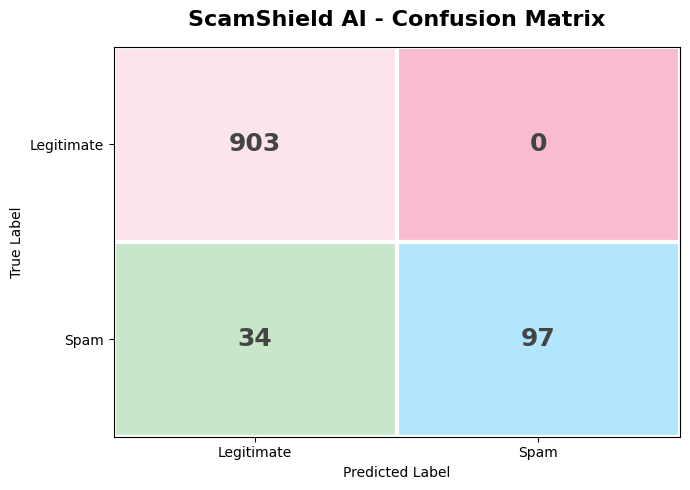

In [53]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred_nb, labels=["ham", "spam"])

fig, ax = plt.subplots(figsize=(7, 5))

# Soft pastel colors
colors = ["#FCE4EC", "#F8BBD0", "#C8E6C9", "#B3E5FC"]

# Background
ax.set_facecolor("#FFF9FC")

# Draw cells manually
for i in range(2):
    for j in range(2):
        color = colors[i * 2 + j]
        ax.add_patch(
            plt.Rectangle(
                (j, i), 1, 1,
                facecolor=color,
                edgecolor="white",
                linewidth=3
            )
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="#444444"
        )

ax.set_xlim(0, 2)
ax.set_ylim(2, 0)

ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])

ax.set_xticklabels(["Legitimate", "Spam"])
ax.set_yticklabels(["Legitimate", "Spam"])

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_title(
    "ScamShield AI - Confusion Matrix",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

## 🎯 Final SVM Model

Based on the model comparison, the Linear SVM is used as the final model for ScamShield AI.

Probability calibration is applied so that the model can provide a spam probability for risk assessment.

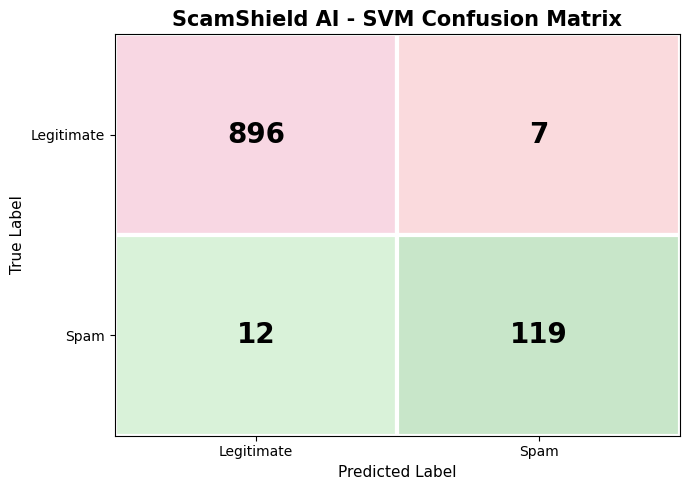

In [58]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Final SVM predictions
y_pred_final_svm = final_svm.predict(X_test_tfidf)

# Confusion Matrix
cm_svm = confusion_matrix(
    y_test,
    y_pred_final_svm,
    labels=["ham", "spam"]
)

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Pink + Light Green colors
colors = [
    "#F8D7E3",
    "#FADADD",
    "#D9F2D9",
    "#C8E6C9"
]

# Draw cells
for i in range(2):
    for j in range(2):

        ax.add_patch(
            plt.Rectangle(
                (j, i),
                1,
                1,
                facecolor=colors[i * 2 + j],
                edgecolor="white",
                linewidth=3
            )
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            cm_svm[i, j],
            ha="center",
            va="center",
            fontsize=20,
            fontweight="bold"
        )

# Labels
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])

ax.set_xticklabels(["Legitimate", "Spam"])
ax.set_yticklabels(["Legitimate", "Spam"])

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

ax.set_title(
    "ScamShield AI - SVM Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

# Set limits
ax.set_xlim(0, 2)
ax.set_ylim(2, 0)

# Light background
ax.set_facecolor("#FFF9FC")

plt.tight_layout()
plt.show()

## 🛡️ Scam Risk Assessment

ScamShield AI analyzes a message using the final SVM model and provides:

- Spam probability
- Scam type
- Number of red flags
- Final risk level

In [55]:
def scamshield_risk_svm(message):

    # Convert message into TF-IDF
    message_tfidf = vectorizer.transform([message])

    # SVM prediction
    prediction = final_svm.predict(message_tfidf)[0]

    # Probability
    probabilities = final_svm.predict_proba(message_tfidf)[0]
    classes = final_svm.classes_

    # Get spam probability
    spam_index = list(classes).index("spam")
    spam_probability = probabilities[spam_index] * 100

    # Red flags
    red_flags = []

    message_lower = message.lower()

    if any(word in message_lower for word in
           ["won", "winner", "prize", "reward", "lottery", "congratulations"]):
        red_flags.append("Prize/reward claim")

    if any(word in message_lower for word in
           ["urgent", "immediately", "now", "hurry", "limited time", "act fast"]):
        red_flags.append("Urgent action requested")

    if any(word in message_lower for word in
           ["₹", "rs", "rupees", "cash", "money", "lakh", "crore"]):
        red_flags.append("Money-related offer")

    if any(word in message_lower for word in
           ["click", "link", "http", "www", "verify"]):
        red_flags.append("Link or verification request")

    if any(word in message_lower for word in
           ["password", "otp", "pin", "bank", "account", "card"]):
        red_flags.append("Personal or financial information requested")

    # Final risk
    if spam_probability >= 70 or len(red_flags) >= 3:
        risk = "HIGH RISK"
    elif spam_probability >= 40 or len(red_flags) >= 2:
        risk = "MEDIUM RISK"
    else:
        risk = "LOW RISK"

    print("SCAMSHIELD AI - SVM RISK ASSESSMENT")
    print("=" * 55)
    print("Model              : Linear SVM")
    print("Prediction         :", prediction.upper())
    print(f"Spam Probability   : {spam_probability:.2f}%")
    print("Red Flags Detected :", len(red_flags))
    print("FINAL RISK         :", risk)

    if red_flags:
        print("\nRED FLAGS:")
        for flag in red_flags:
            print(" -", flag)

    print("=" * 55)

In [56]:
scamshield_risk_svm(
    "Your bank account will be blocked. Verify your OTP immediately by clicking this link."
)

SCAMSHIELD AI - SVM RISK ASSESSMENT
Model              : Linear SVM
Prediction         : SPAM
Spam Probability   : 76.26%
Red Flags Detected : 3
FINAL RISK         : HIGH RISK

RED FLAGS:
 - Urgent action requested
 - Link or verification request
 - Personal or financial information requested


In [57]:
scamshield_risk_svm(
    "Hi, your class is scheduled at 10 AM tomorrow. Please bring your assignment."
)

SCAMSHIELD AI - SVM RISK ASSESSMENT
Model              : Linear SVM
Prediction         : HAM
Spam Probability   : 0.29%
Red Flags Detected : 0
FINAL RISK         : LOW RISK


In [59]:
import joblib

joblib.dump(final_svm, "scamshield_svm_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
